### Step 0 — Selected Company

I selected **Ferrari N.V. (RACE)** for this company fundamental deep dive. Ferrari belongs to the assigned European geographic group and operates in the **Auto Manufacturers** industry within the **Consumer Cyclical** sector.

The choice is motivated by Ferrari’s distinctive position within the automotive industry. Although it is classified as an auto manufacturer, Ferrari has a premium and luxury-oriented business model, based on brand strength, pricing power and limited production volumes. This makes it interesting to compare with both traditional auto manufacturers and other large companies.

Based on a preliminary inspection of the dataset, Ferrari also appears suitable for a fundamental analysis because it has valid observations for the main required metrics. In particular, it combines a large market capitalization, strong profitability indicators, positive free cash flow and relatively high valuation multiples. This makes Ferrari a useful case to investigate whether a premium valuation is supported by profitability, growth and financial strength.

In [2]:
# ============================================================
# Step 0 — Select a Company
# ============================================================


selected_symbol = "RACE" # Ferrari

In [3]:
# ============================================================
# Step 1 — Data Preparation
# ============================================================

# pandas is used for data loading, cleaning, filtering and aggregation.
import pandas as pd

# numpy is useful for numerical operations and for handling infinite values.
import numpy as np

# matplotlib is used for plotting charts.
import matplotlib.pyplot as plt

# FuncFormatter helps format axis labels in a readable way.
from matplotlib.ticker import FuncFormatter

# Display settings to make tables easier to inspect.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Default chart settings.
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = False

In [4]:
# ============================================================
# Helper functions for cleaner charts
# ============================================================

# Format values expressed in USD billions.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Format values expressed as percentages.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Remove unnecessary chart borders.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Add labels to horizontal bar charts.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=10)

In [5]:
# ============================================================
# Load raw dataset
# ============================================================

# Load the dataset 
df_raw = pd.read_csv("data/Symbol_Info_extended.csv")

# Inspect the raw dataset dimensions and first rows.
print("Raw dataset shape:", df_raw.shape)

display(df_raw.head())

Raw dataset shape: (3070, 21)


,symbol,company_name,sector,industry,country,market_cap,net_income,total_revenue,return_on_assets,return_on_equity,profit_margins,pe_trailing,pe_forward,earnings_growth,price_to_sales,price_to_book,revenue_growth,debt_to_equity,dividend_yield,payout_ratio,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,1.290000e+09,7.065000e+09,0.08533,0.19946,0.18259,25.377481,17.515205,-0.036,4.598437,4.704534,0.070,51.390,0.89,0.2205,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,1.027000e+09,1.265500e+10,0.04241,0.15427,0.08171,18.302563,10.659156,-0.227,1.488460,2.759500,-0.052,37.019,0.56,0.1026,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,2.020000e+08,5.599400e+10,0.01846,NaN,0.00361,44.677420,6.256155,NaN,0.163592,-2.246918,0.108,NaN,NaN,0.0000,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,8.420000e+07,6.108000e+08,0.12664,1.11725,0.13785,30.459576,12.513987,0.264,4.175381,32.910347,0.393,346.579,0.56,0.0553,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-4.333700e+07,5.070000e+08,-0.03317,-0.06126,-0.08548,NaN,38.032272,NaN,28.724379,12.958943,0.514,25.356,NaN,0.0000,-4.455833e+08


In [ ]:
# ============================================================
# Select variables required 
# ============================================================



required_columns = [
    "symbol",
    "company_name",
    "sector",
    "industry",
    "country",
    "market_cap",
    "return_on_assets",
    "return_on_equity",
    "profit_margins",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow"
]

# Create a working DataFrame containing only the variables needed for the homework.
df_work = df_raw[required_columns].copy()

print("Working dataset shape:", df_work.shape)

display(df_work.head())

Working dataset shape: (3070, 14)


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,-2.246918,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08


In [ ]:
# ============================================================
# Apply cleaning rules
# ============================================================

# Replace infinite values with NaN.
df_work = df_work.replace([np.inf, -np.inf], np.nan)

# Remove companies with non-positive market capitalization.
df_work = df_work[df_work["market_cap"] > 0].copy()

# Valuation multiples less than or equal to zero are not comparable with positive multiples.
# We keep the company in the dataset but set invalid valuation values to NaN.
df_work.loc[df_work["pe_trailing"] <= 0, "pe_trailing"] = np.nan
df_work.loc[df_work["price_to_book"] <= 0, "price_to_book"] = np.nan

print("Cleaned working dataset shape:", df_work.shape)

Cleaned working dataset shape: (2970, 14)


In [8]:
# ============================================================
# Create readable financial variables
# ============================================================

# Monetary values are converted into USD billions for easier chart interpretation.
# The original columns are kept unchanged.
df_work["market_cap_b"] = df_work["market_cap"] / 1_000_000_000
df_work["free_cashflow_b"] = df_work["free_cashflow"] / 1_000_000_000

# These ratio variables are stored in decimal form in the dataset.
# We convert them into percentage points for charts and interpretation.
df_work["profit_margin_pct"] = df_work["profit_margins"] * 100
df_work["return_on_assets_pct"] = df_work["return_on_assets"] * 100
df_work["return_on_equity_pct"] = df_work["return_on_equity"] * 100
df_work["revenue_growth_pct"] = df_work["revenue_growth"] * 100
# debt_to_equity is not multiplied by 100 because the dataset already expresses it as a percentage.

display(df_work.head())

,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow,market_cap_b,free_cashflow_b,profit_margin_pct,return_on_assets_pct,return_on_equity_pct,revenue_growth_pct
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08,32.487961,0.855875,18.259001,8.533000,19.945998,7.0
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09,18.836457,1.087375,8.171000,4.241000,15.427000,-5.2
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08,9.160185,0.861125,0.361000,1.846000,NaN,10.8
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08,2.550323,0.120800,13.785000,12.663999,111.725000,39.3
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08,14.563260,-0.445583,-8.548001,-3.317000,-6.126000,51.4


In [9]:
# ============================================================
# Diagnostic check — Missing values after cleaning
# ============================================================

# This table is only used to inspect data availability after the main cleaning rules.
# Missing values are not removed globally: they will be handled metric-by-metric in each specific analysis

missing_summary = pd.DataFrame({
    "column": df_work.columns,
    "dtype": df_work.dtypes.astype(str).values,
    "missing_values": df_work.isna().sum().values,
    "missing_pct": (df_work.isna().mean().values * 100).round(2)
})

missing_summary.sort_values("missing_pct", ascending=False)

,column,dtype,missing_values,missing_pct
9,pe_trailing,float64,882,29.70
12,debt_to_equity,float64,443,14.92
15,free_cashflow_b,float64,387,13.03
13,free_cashflow,float64,387,13.03
10,price_to_book,float64,172,5.79
18,return_on_equity_pct,float64,163,5.49
7,return_on_equity,float64,163,5.49
11,revenue_growth,float64,123,4.14
19,revenue_growth_pct,float64,123,4.14
17,return_on_assets_pct,float64,20,0.67


In [10]:
# ============================================================
# Check selected company
# ============================================================


# Extract Ferrari's row after cleaning.
selected_company = df_work[df_work["symbol"] == selected_symbol].copy()

# Display the selected company's main identification and financial variables.
display(
    selected_company[
        [
            "symbol",
            "company_name",
            "sector",
            "industry",
            "country",
            "market_cap_b",
            "profit_margin_pct",
            "return_on_assets_pct",
            "return_on_equity_pct",
            "pe_trailing",
            "price_to_book",
            "revenue_growth_pct",
            "debt_to_equity",
            "free_cashflow_b"
        ]
    ]
)

,symbol,company_name,sector,industry,country,market_cap_b,profit_margin_pct,return_on_assets_pct,return_on_equity_pct,pe_trailing,price_to_book,revenue_growth_pct,debt_to_equity,free_cashflow_b
2269,RACE,Ferrari N.V.,Consumer Cyclical,Auto Manufacturers,Italy,61.356921,22.187,13.083,41.968,33.3244,13.082135,3.2,72.246,0.98585


In [11]:
# ============================================================
# Step 2 — Build Peer Groups
# ============================================================

# Create a clean label column for charts.
# If company_name is missing or empty, the symbol is used instead.
df_work["company_name"] = df_work["company_name"].replace("", np.nan)

df_work["label"] = np.where(
    df_work["company_name"].notna(),
    df_work["company_name"],
    df_work["symbol"]
)

# Ensure labels are strings because Matplotlib requires categorical labels to be text.
df_work["label"] = df_work["label"].astype(str)

# Re-create selected_company after the label column has been added.
# This is important because selected_company is later concatenated into peer groups if Ferrari is not in the top 10.
selected_company = df_work[df_work["symbol"] == selected_symbol].copy()

# Store Ferrari's industry, country and market capitalization.
selected_industry = selected_company["industry"].iloc[0]
selected_country = selected_company["country"].iloc[0]
selected_market_cap = selected_company["market_cap"].iloc[0]

print("Selected company:", selected_symbol)
print("Industry:", selected_industry)
print("Country:", selected_country)
print("Market cap:", f"{selected_market_cap / 1_000_000_000:,.2f}B")

Selected company: RACE
Industry: Auto Manufacturers
Country: Italy
Market cap: 61.36B


In [12]:
# ============================================================
# Group A — Same Industry
# ============================================================

# Select all companies in the same industry as Ferrari.
group_a_industry = df_work[
    df_work["industry"] == selected_industry
].copy()

# Sort by market capitalization and keep the top 10 companies.
group_a_industry = group_a_industry.sort_values(
    "market_cap",
    ascending=False
).head(10).copy()

# If Ferrari is not in the top 10, add it to the group.
if selected_symbol not in group_a_industry["symbol"].values:
    group_a_industry = pd.concat(
        [group_a_industry, selected_company],
        axis=0
    )

# Remove possible duplicates.
group_a_industry = group_a_industry.drop_duplicates(subset="symbol").copy()

print("Group A — Same Industry size:", len(group_a_industry))

display(
    group_a_industry[
        ["symbol", "label", "country", "sector", "industry", "market_cap_b"]
    ].sort_values("market_cap_b", ascending=False)
)

Group A — Same Industry size: 9


,symbol,label,country,sector,industry,market_cap_b
2758,TSLA,"Tesla, Inc.",United States,Consumer Cyclical,Auto Manufacturers,1599.975981
1196,GM,General Motors Company,United States,Consumer Cyclical,Auto Manufacturers,71.042204
2269,RACE,Ferrari N.V.,Italy,Consumer Cyclical,Auto Manufacturers,61.356921
1005,F,Ford Motor Company,United States,Consumer Cyclical,Auto Manufacturers,59.491463
1700,MAHMF,Mahindra & Mahindra Limited,India,Consumer Cyclical,Auto Manufacturers,42.026680
2330,RIVN,"Rivian Automotive, Inc.",United States,Consumer Cyclical,Auto Manufacturers,19.095560
1907,NIO,NIO Inc.,China,Consumer Cyclical,Auto Manufacturers,13.029468
1592,LCID,"Lucid Group, Inc.",United States,Consumer Cyclical,Auto Manufacturers,2.279100
2229,PSNY,Polestar Automotive Holding UK PLC,Sweden,Consumer Cyclical,Auto Manufacturers,2.036047


In [ ]:
# ============================================================
# Group B — Same Geographic Group
# ============================================================

# Geographic Group 5 — Europe (Student ID: 100004719)
europe_countries = [
    "Ireland",
    "Italy",
    "Germany",
    "Netherlands",
    "Luxembourg",
    "Spain",
    "France"
]

# Select all companies belonging to the assigned European geographic group.
group_b_geo = df_work[
    df_work["country"].isin(europe_countries)
].copy()

# Sort by market capitalization and keep the top 10 companies.
group_b_geo = group_b_geo.sort_values(
    "market_cap",
    ascending=False
).head(10).copy()

# If Ferrari is not in the top 10, add it to the group.
if selected_symbol not in group_b_geo["symbol"].values:
    group_b_geo = pd.concat(
        [group_b_geo, selected_company],
        axis=0
    )

# Remove possible duplicates.
group_b_geo = group_b_geo.drop_duplicates(subset="symbol").copy()

print("Group B — Same Geographic Group size:", len(group_b_geo))

display(
    group_b_geo[
        ["symbol", "label", "country", "sector", "industry", "market_cap_b"]
    ].sort_values("market_cap_b", ascending=False)
)

Group B — Same Geographic Group size: 11


,symbol,label,country,sector,industry,market_cap_b
237,ASML,ASML Holding N.V.,Netherlands,Technology,Semiconductor Equipment & Materials,629.348499
967,ETN,Eaton Corporation plc,Ireland,Industrials,Specialty Industrial Machinery,151.961207
2115,PDD,PDD Holdings Inc.,Ireland,Consumer Cyclical,Internet Retail,134.539428
36,ACN,Accenture plc,Ireland,Technology,Information Technology Services,110.310597
1737,MDT,Medtronic plc,Ireland,Healthcare,Medical Devices,100.913357
2763,TT,Trane Technologies plc,Ireland,Industrials,Building Products & Equipment,99.700433
1486,JCI,Johnson Controls International plc,Ireland,Industrials,Building Products & Equipment,84.415594
1986,NXPI,NXP Semiconductors N.V.,Netherlands,Technology,Semiconductors,79.899517
180,AON,Aon plc,Ireland,Financial Services,Insurance Brokers,69.365522
693,CRH,CRH plc,Ireland,Basic Materials,Building Materials,67.067257


In [ ]:
# ============================================================
# Group C — Closest Market Capitalization
# ============================================================

# Compute the absolute distance between each company's market cap and Ferrari's market cap.
df_size = df_work.copy()
df_size["market_cap_distance"] = (
    df_size["market_cap"] - selected_market_cap
).abs()

# Select the 10 companies with the closest market capitalization.
group_c_size = df_size.sort_values(
    "market_cap_distance",
    ascending=True
).head(10).copy()

print("Group C — Closest Market Capitalization size:", len(group_c_size))

display(
    group_c_size[
        [
            "symbol",
            "label",
            "country",
            "sector",
            "industry",
            "market_cap_b",
            "market_cap_distance"
        ]
    ].sort_values("market_cap_distance", ascending=True)
)

Group C — Closest Market Capitalization size: 10


,symbol,label,country,sector,industry,market_cap_b,market_cap_distance
2269,RACE,Ferrari N.V.,Italy,Consumer Cyclical,Auto Manufacturers,61.356921,0.000000e+00
1959,NU,Nu Holdings Ltd.,Brazil,Financial Services,Banks - Regional,61.889962,5.330412e+08
2568,SRE,Sempra,United States,Utilities,Utilities - Diversified,60.662440,6.944809e+08
2675,TFC,Truist Financial Corporation,United States,Financial Services,Banks - Regional,60.275630,1.081291e+09
74,AFL,Aflac Incorporated,United States,Financial Services,Insurance - Life,59.988959,1.367962e+09
2536,SNOW,Snowflake Inc.,United States,Technology,Software - Application,59.685020,1.671901e+09
774,D,"Dominion Energy, Inc.",United States,Utilities,Utilities - Regulated Electric,59.516609,1.840312e+09
1005,F,Ford Motor Company,United States,Consumer Cyclical,Auto Manufacturers,59.491463,1.865458e+09
2595,STM,STMicroelectronics N.V.,Netherlands,Technology,Semiconductors,59.424776,1.932145e+09
2737,TRGP,Targa Resources Corp.,United States,Energy,Oil & Gas Midstream,59.402699,1.954222e+09


# Step 3 — Business Question 1: Is the Company Profitable? 

Profitability is evaluated using two metrics:
 1. Profit margin: how much of revenue becomes profit.
 2. Return on equity: profitability relative to shareholders' equity.

 Missing values are removed only for the specific metric used in each chart.



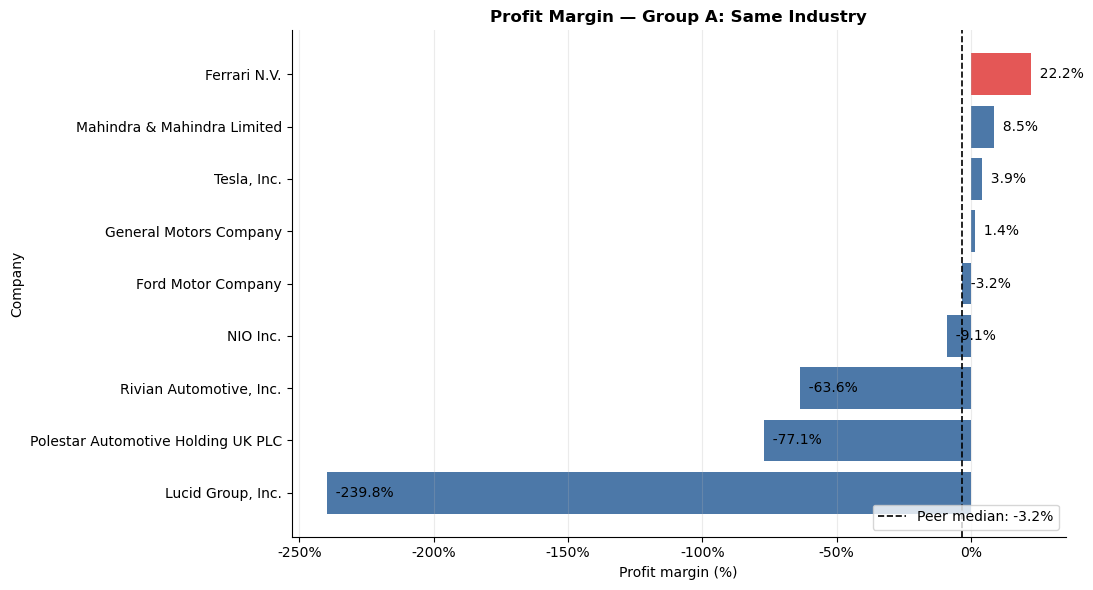

In [15]:
# ============================================================
# Step 3A — Profit Margin: Group A, Same Industry
# ============================================================

metric = "profit_margin_pct"
group_name = "Group A — Same Industry"

# Remove missing values only for the metric used in this chart.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort companies by profitability.
plot_df = plot_df.sort_values(metric, ascending=True)

# Compute the peer median using available observations.
peer_median = plot_df[metric].median()

# Highlight Ferrari.
bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.set_title("Profit Margin — Group A: Same Industry")
ax.set_xlabel("Profit margin (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



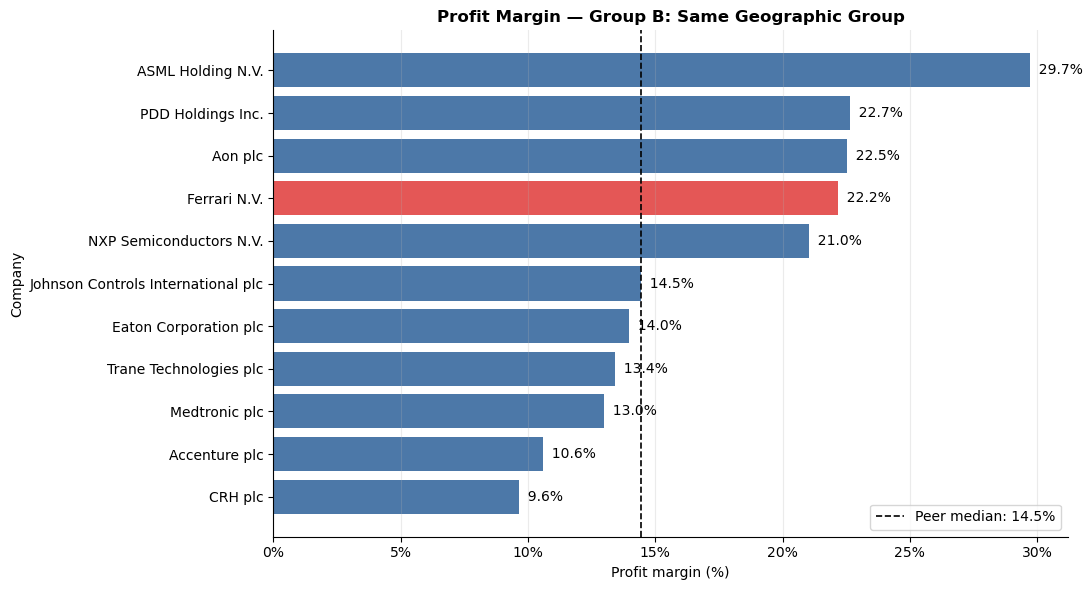

In [16]:
# ============================================================
# Step 3B — Profit Margin: Group B, Same Geographic Group
# ============================================================

metric = "profit_margin_pct"
group_name = "Group B — Same Geographic Group"

plot_df = group_b_geo.dropna(subset=[metric]).copy()
plot_df = plot_df.sort_values(metric, ascending=True)

peer_median = plot_df[metric].median()

bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.set_title("Profit Margin — Group B: Same Geographic Group")
ax.set_xlabel("Profit margin (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


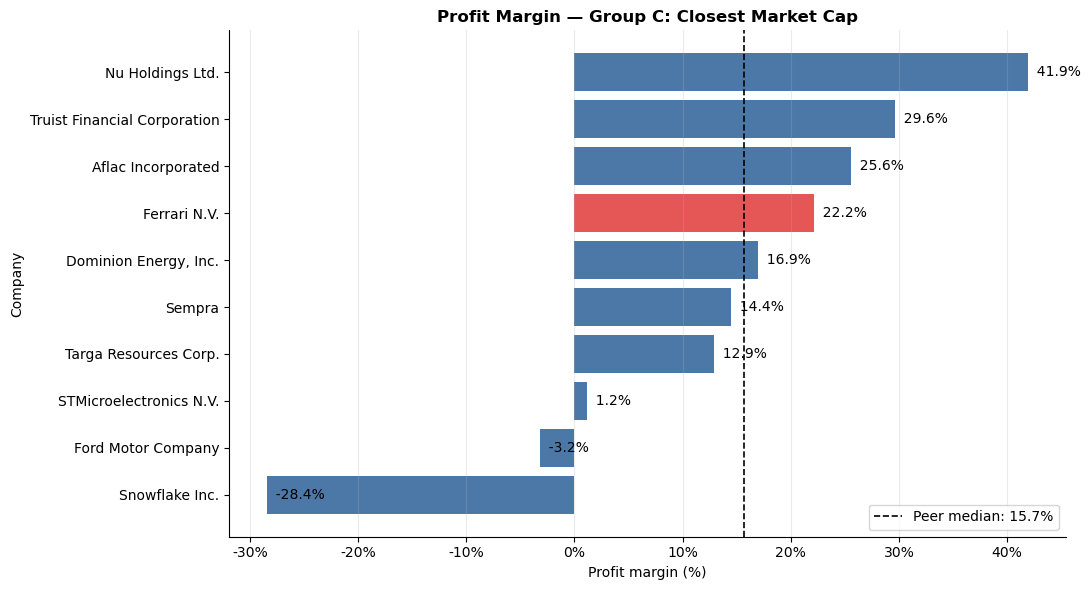

In [17]:
# ============================================================
# Step 3C — Profit Margin: Group C, Closest Market Cap
# ============================================================

metric = "profit_margin_pct"
group_name = "Group C — Closest Market Cap"

plot_df = group_c_size.dropna(subset=[metric]).copy()
plot_df = plot_df.sort_values(metric, ascending=True)

peer_median = plot_df[metric].median()

bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.set_title("Profit Margin — Group C: Closest Market Cap")
ax.set_xlabel("Profit margin (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



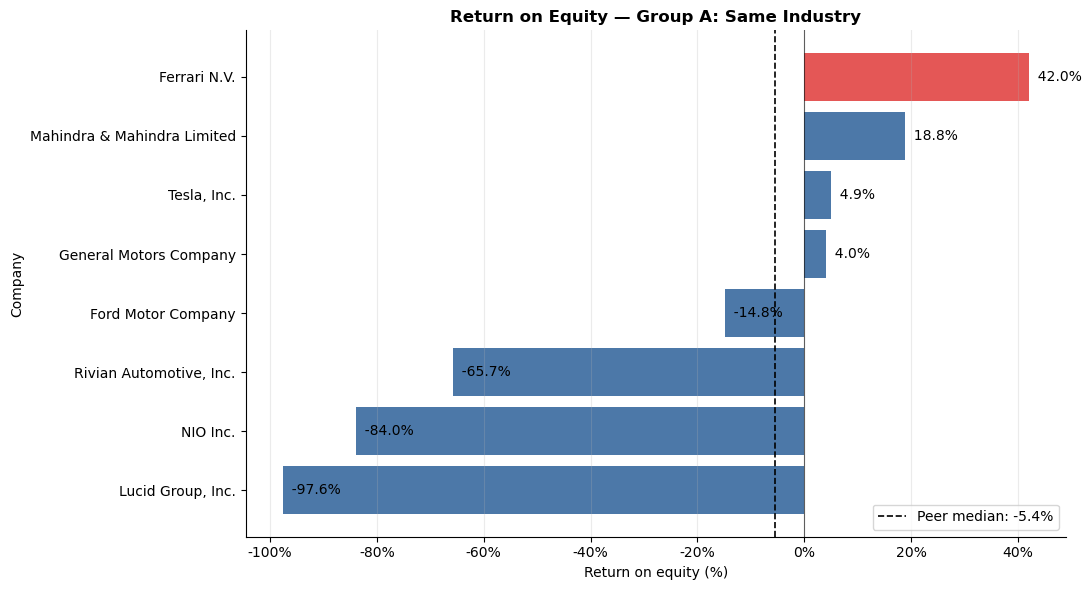

In [18]:
# ============================================================
# Step 3D — Return on Equity: Group A, Same Industry
# ============================================================

metric = "return_on_equity_pct"
group_name = "Group A — Same Industry"

# Remove missing values only for ROE.
plot_df = group_a_industry.dropna(subset=[metric]).copy()
plot_df = plot_df.sort_values(metric, ascending=True)

peer_median = plot_df[metric].median()

bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

# Median line.
ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.6,
    
)

ax.set_title("Return on Equity — Group A: Same Industry")
ax.set_xlabel("Return on equity (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



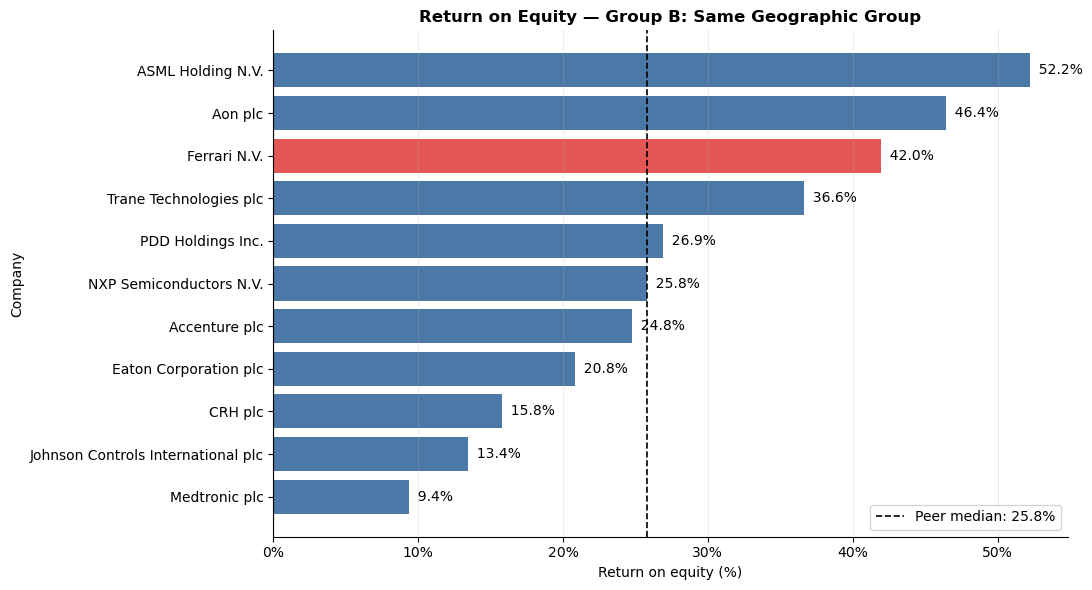

In [19]:
# ============================================================
# Step 3E — Return on Equity: Group B, Same Geographic Group
# ============================================================

metric = "return_on_equity_pct"
group_name = "Group B — Same Geographic Group"

plot_df = group_b_geo.dropna(subset=[metric]).copy()
plot_df = plot_df.sort_values(metric, ascending=True)

peer_median = plot_df[metric].median()

bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.6,
)

ax.set_title("Return on Equity — Group B: Same Geographic Group")
ax.set_xlabel("Return on equity (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()




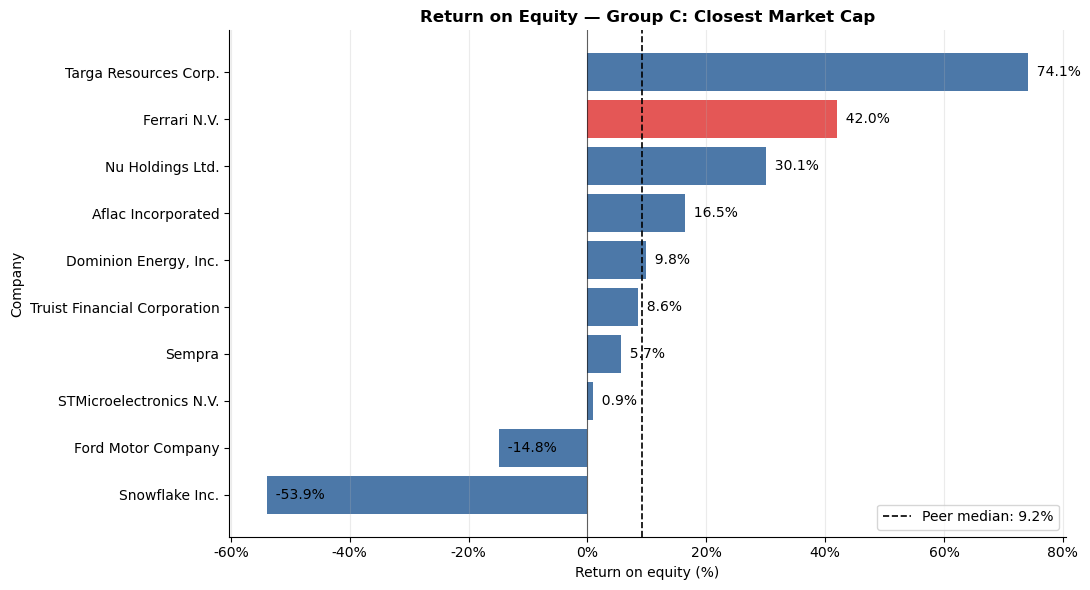

In [20]:
# ============================================================
# Step 3F — Return on Equity: Group C, Closest Market Cap
# ============================================================

metric = "return_on_equity_pct"
group_name = "Group C — Closest Market Cap"

plot_df = group_c_size.dropna(subset=[metric]).copy()
plot_df = plot_df.sort_values(metric, ascending=True)

peer_median = plot_df[metric].median()

bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.6,
)

ax.set_title("Return on Equity — Group C: Closest Market Cap")
ax.set_xlabel("Return on equity (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()



### Interpretation — Profitability

Ferrari shows a strong profitability profile across both selected metrics: **profit margin** and **return on equity**. The results are consistent across the three peer groups, since Ferrari is above the peer median in every comparison.

For **profit margin**, Ferrari reports a margin of about **22.2%**. This is far above the median of the same-industry peer group, which is approximately **-3.2%**. This difference is particularly relevant because several Auto Manufacturers peers have weak or negative margins, reflecting the difficult conditions currently affecting the automotive industry, including transition costs, competitive pressure and weak profitability among some growth-oriented manufacturers. In this context, Ferrari stands out clearly, suggesting that its premium business model and pricing power make it structurally different from many traditional or EV-focused auto manufacturers.

Ferrari also remains above the median when compared with the broader European geographic group and with companies of similar market capitalization. In Group B, Ferrari’s profit margin is above the peer median of about **14.5%**, placing it among the most profitable firms in the European peer group. In Group C, Ferrari is also above the market-cap peer median of about **15.7%**, confirming that its profitability is strong not only within the automotive industry but also relative to companies of comparable size.

The **return on equity** results confirm the same pattern. Ferrari’s ROE is about **42.0%**, well above the same-industry median of around **-5.4%**. This is a strong signal of shareholder profitability, especially because several auto manufacturers report negative ROE. Ferrari is also above the median in the European peer group, where the median ROE is about **25.8%**, and in the closest-market-cap group, where the median is about **9.2%**.

Overall, the two profitability metrics are highly consistent. Both profit margin and ROE indicate that Ferrari is not only profitable in absolute terms, but also significantly more profitable than the typical peer across all three comparison groups. This supports the idea that Ferrari’s financial profile is closer to a premium luxury-oriented business than to a standard mass-market auto manufacturer.



### Step 4 — Business Question 2: Is the Company Expensive or Cheap?

Valuation is evaluated using only **Group A — Same Industry** peers, because valuation multiples are more meaningful when companies operate in the same industry. The analysis uses two valuation metrics: **P/E trailing** and **price-to-book**. 

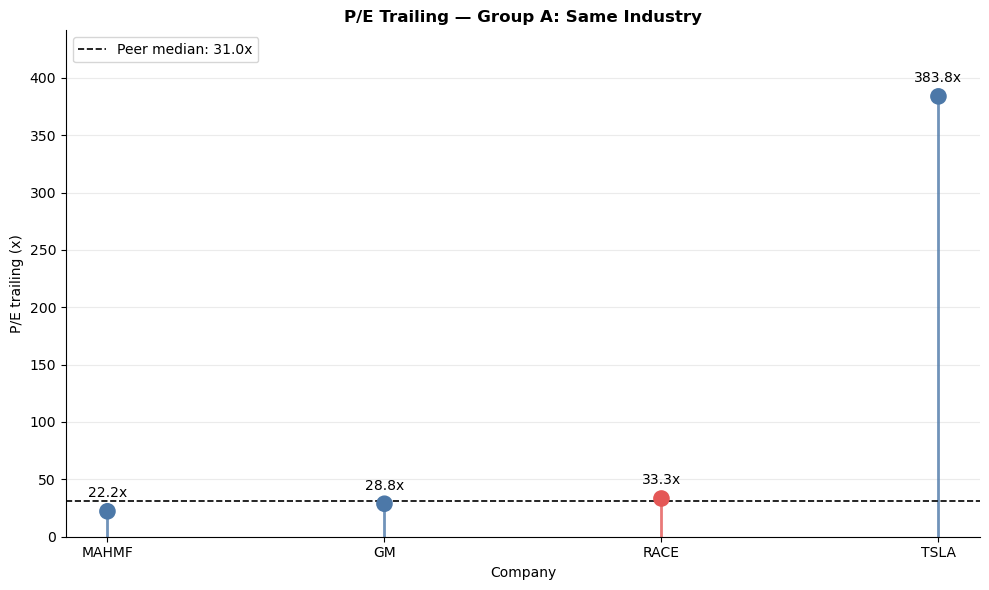

In [ ]:
# ============================================================
# Step 4A — P/E Trailing: Group A, Same Industry
# ============================================================

metric = "pe_trailing"

# Remove missing values only for the metric used in this chart.
# Companies with invalid or non-positive P/E are not included in the valuation comparison.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort valuation multiples in ascending order, as required by the homework instructions.
plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)

# Compute the peer median using available valid observations.
peer_median = plot_df[metric].median()

# Create numeric x positions for the lollipop chart.
x_pos = np.arange(len(plot_df))

# Highlight Ferrari.
colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(10, 6))

# Draw thin vertical lines from zero to each company value.
ax.vlines(
    x=x_pos,
    ymin=0,
    ymax=plot_df[metric],
    color=colors,
    linewidth=2,
    alpha=0.8
)

# Draw dots at the top of each line.
ax.scatter(
    x_pos,
    plot_df[metric],
    color=colors,
    s=120,
    zorder=3
)

# Add peer median line.
ax.axhline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}x"
)

# Add value labels above the dots.
ymax = plot_df[metric].max()
label_offset = ymax * 0.025

for i, value in enumerate(plot_df[metric]):
    ax.text(
        i,
        value + label_offset,
        f"{value:.1f}x",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("P/E Trailing — Group A: Same Industry")
ax.set_xlabel("Company")
ax.set_ylabel("P/E trailing (x)")

# Use symbols on the x-axis to keep the chart readable.
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["symbol"], rotation=0)

# Add space above labels.
ax.set_ylim(0, ymax * 1.15)

ax.grid(axis="y", alpha=0.25)

clean_spines(ax)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()


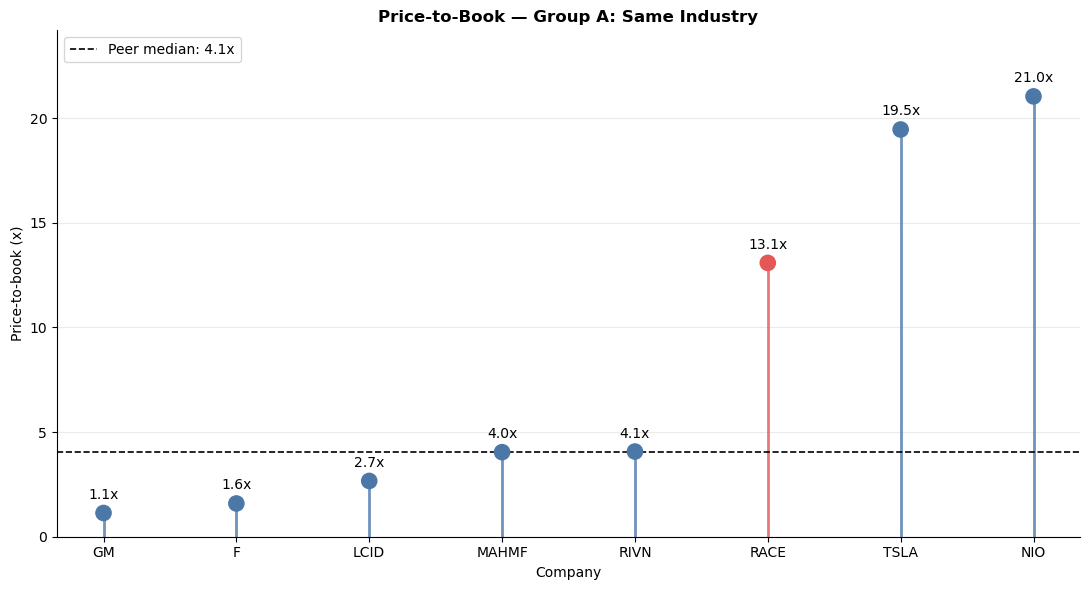

In [ ]:
# ============================================================
# Step 4B — Price-to-Book: Group A, Same Industry
# ============================================================

metric = "price_to_book"

# Remove missing values only for the metric used in this chart.
# Companies with invalid or non-positive P/B are not included in the valuation comparison.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort valuation multiples in ascending order, as required by the homework instructions.
plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)

# Compute the peer median using available valid observations.
peer_median = plot_df[metric].median()

# Create numeric x positions for the lollipop chart.
x_pos = np.arange(len(plot_df))

# Highlight Ferrari.
colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

# Draw thin vertical lines from zero to each company value.
ax.vlines(
    x=x_pos,
    ymin=0,
    ymax=plot_df[metric],
    color=colors,
    linewidth=2,
    alpha=0.8
)

# Draw dots at the top of each line.
ax.scatter(
    x_pos,
    plot_df[metric],
    color=colors,
    s=120,
    zorder=3
)

# Add peer median line.
ax.axhline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}x"
)

# Add value labels above the dots.
ymax = plot_df[metric].max()
label_offset = ymax * 0.025

for i, value in enumerate(plot_df[metric]):
    ax.text(
        i,
        value + label_offset,
        f"{value:.1f}x",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Price-to-Book — Group A: Same Industry")
ax.set_xlabel("Company")
ax.set_ylabel("Price-to-book (x)")

# Use symbols on the x-axis to keep the chart readable.
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["symbol"], rotation=0)

# Add space above labels.
ax.set_ylim(0, ymax * 1.15)

ax.grid(axis="y", alpha=0.25)

clean_spines(ax)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Interpretation — Valuation

Ferrari appears to trade at a **premium valuation** relative to its same-industry peers. Looking at **P/E trailing**, Ferrari has a multiple of about **33.3x**, slightly above the peer median of approximately **31.0x** (this plot has only 4 values because of missing values). This suggests that Ferrari is not cheap on an earnings basis, although it is not the most extreme case in the group. Tesla is a clear outlier, with a P/E of about **383.8x**, which strongly reflects market expectations and growth-oriented valuation dynamics.

The premium is more evident when looking at **price-to-book**. Ferrari trades at about **13.1x book value**, compared with a peer median of about **4.1x**. This places Ferrari well above traditional auto manufacturers such as General Motors and Ford, and closer to high-expectation companies such as Tesla and NIO. Therefore, based on price-to-book, Ferrari appears clearly expensive relative to the typical Auto Manufacturers peer.

However, this premium valuation should not be interpreted automatically as overvaluation. The profitability analysis in Step 3 showed that Ferrari has much stronger fundamentals than the median peer, with both profit margin and return on equity well above the comparison groups. Ferrari’s high valuation is therefore partly consistent with its premium business model, brand strength, pricing power and superior profitability.

At the same time, lower valuation multiples among some peers should not automatically be seen as better investment opportunities. In the automotive industry, low multiples may reflect weak profitability, negative margins, high competitive pressure or lower expected growth rather than undervaluation. Overall, Ferrari appears expensive but supported by its fundamentals.

### Step 5 — Business Question 3: Is the Company Growing?

Growth is evaluated using **revenue growth**. Ferrari is compared with the three peer groups defined in Step 2: same industry, same geographic group and closest market capitalization. 

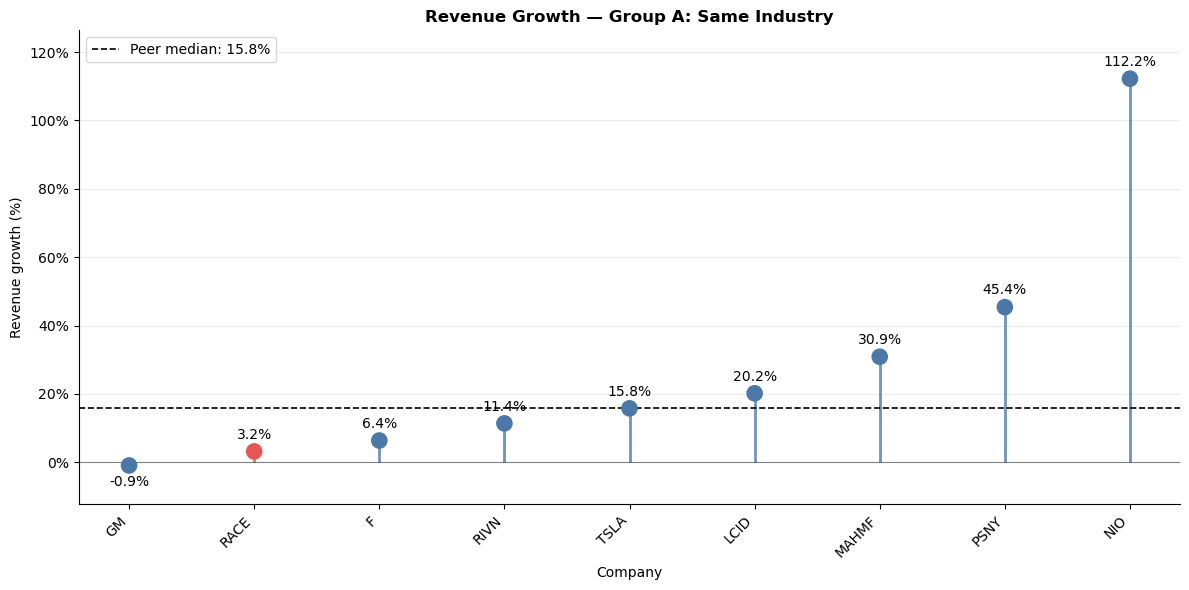

In [ ]:
# ============================================================
# Step 5A — Revenue Growth: Group A, Same Industry
# ============================================================

metric = "revenue_growth_pct"

# Remove missing values only for the metric used in this chart.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort companies by revenue growth.
plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)

# Compute the peer median using available observations.
peer_median = plot_df[metric].median()

# Create numeric x positions for the lollipop chart.
x_pos = np.arange(len(plot_df))

# Highlight Ferrari.
colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(12, 6))

# Draw vertical lines from zero to each company value.
ax.vlines(
    x=x_pos,
    ymin=0,
    ymax=plot_df[metric],
    color=colors,
    linewidth=2,
    alpha=0.8
)

# Draw dots at the end of each line.
ax.scatter(
    x_pos,
    plot_df[metric],
    color=colors,
    s=120,
    zorder=3
)

# Add peer median line.
ax.axhline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

# Add zero line to separate positive and negative revenue growth.
ax.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.45
)

# Add value labels.
ymax = plot_df[metric].max()
ymin = plot_df[metric].min()
label_offset = (ymax - ymin) * 0.025

for i, value in enumerate(plot_df[metric]):
    if value >= 0:
        va = "bottom"
        y_text = value + label_offset
    else:
        va = "top"
        y_text = value - label_offset

    ax.text(
        i,
        y_text,
        f"{value:.1f}%",
        ha="center",
        va=va,
        fontsize=10
    )

ax.set_title("Revenue Growth — Group A: Same Industry")
ax.set_xlabel("Company")
ax.set_ylabel("Revenue growth (%)")

# Use tickers on the x-axis to keep the chart readable.
ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["symbol"], rotation=45, ha="right")

# Format y-axis as percentage.
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

# Add vertical space for labels.
ax.set_ylim(ymin - abs(label_offset) * 4, ymax + abs(label_offset) * 5)

ax.grid(axis="y", alpha=0.25)

clean_spines(ax)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

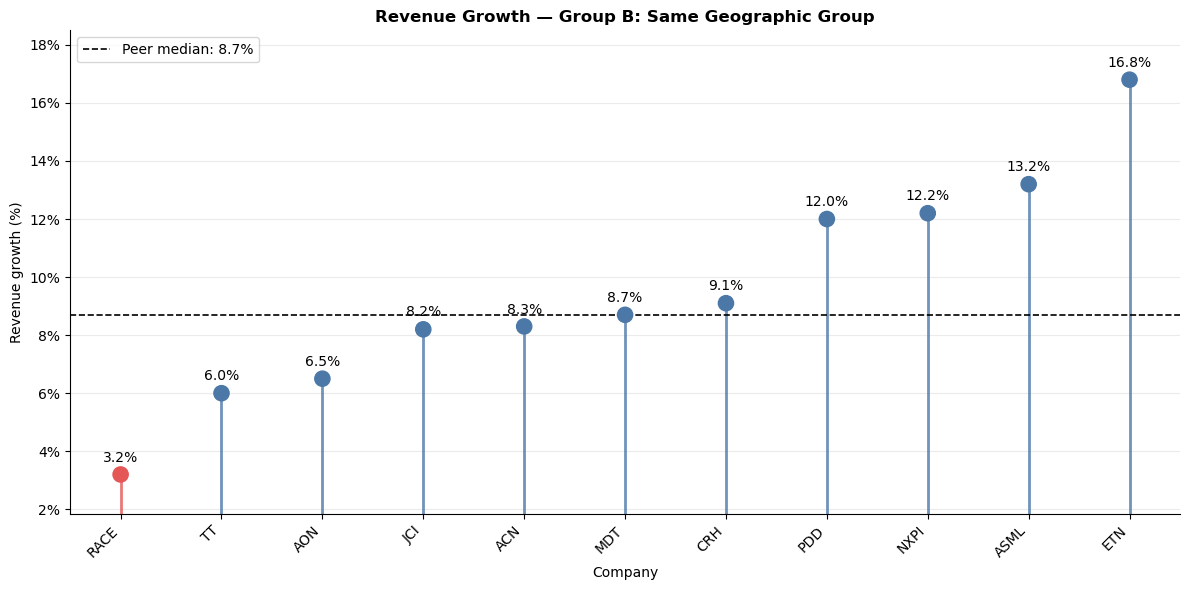

In [24]:
# ============================================================
# Step 5B — Revenue Growth: Group B, Same Geographic Group
# Vertical lollipop chart
# ============================================================

metric = "revenue_growth_pct"

# Remove missing values only for the metric used in this chart.
plot_df = group_b_geo.dropna(subset=[metric]).copy()

# Sort companies by revenue growth.
plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)

# Compute the peer median using available observations.
peer_median = plot_df[metric].median()

# Create numeric x positions for the lollipop chart.
x_pos = np.arange(len(plot_df))

# Highlight Ferrari.
colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(12, 6))

# Draw vertical lines from zero to each company value.
ax.vlines(
    x=x_pos,
    ymin=0,
    ymax=plot_df[metric],
    color=colors,
    linewidth=2,
    alpha=0.8
)

# Draw dots at the end of each line.
ax.scatter(
    x_pos,
    plot_df[metric],
    color=colors,
    s=120,
    zorder=3
)

# Add peer median line.
ax.axhline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

# Add zero line to separate positive and negative revenue growth.
ax.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.45
)

# Add value labels.
ymax = plot_df[metric].max()
ymin = plot_df[metric].min()
label_offset = (ymax - ymin) * 0.025

for i, value in enumerate(plot_df[metric]):
    if value >= 0:
        va = "bottom"
        y_text = value + label_offset
    else:
        va = "top"
        y_text = value - label_offset

    ax.text(
        i,
        y_text,
        f"{value:.1f}%",
        ha="center",
        va=va,
        fontsize=10
    )

ax.set_title("Revenue Growth — Group B: Same Geographic Group")
ax.set_xlabel("Company")
ax.set_ylabel("Revenue growth (%)")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["symbol"], rotation=45, ha="right")

ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

ax.set_ylim(ymin - abs(label_offset) * 4, ymax + abs(label_offset) * 5)

ax.grid(axis="y", alpha=0.25)

clean_spines(ax)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

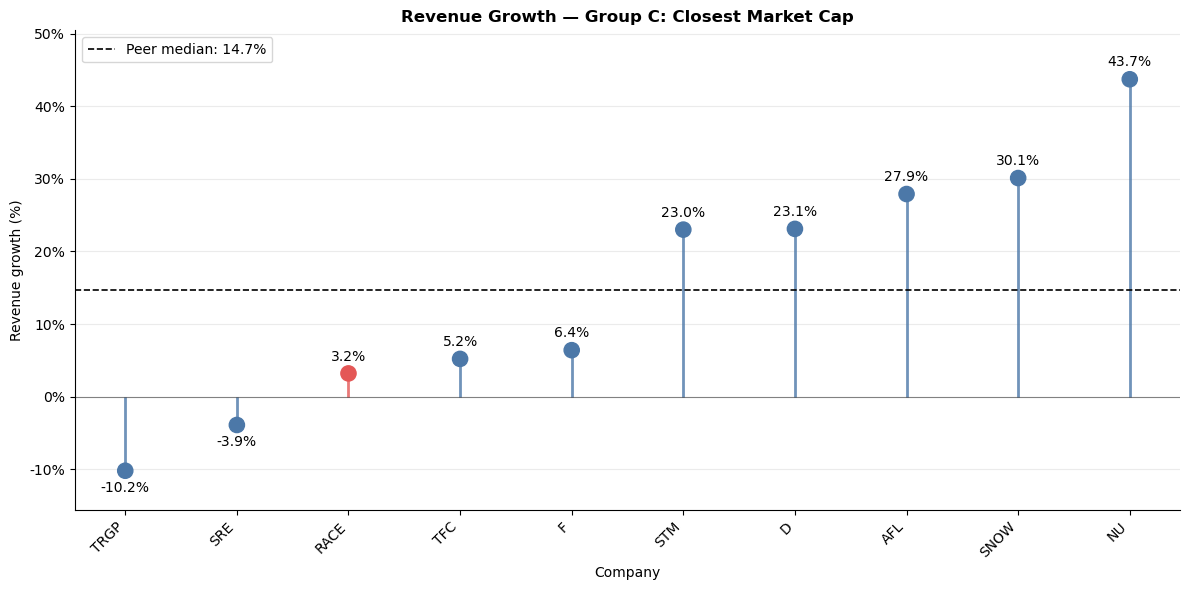

In [25]:
# ============================================================
# Step 5C — Revenue Growth: Group C, Closest Market Cap
# Vertical lollipop chart
# ============================================================

metric = "revenue_growth_pct"

# Remove missing values only for the metric used in this chart.
plot_df = group_c_size.dropna(subset=[metric]).copy()

# Sort companies by revenue growth.
plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)

# Compute the peer median using available observations.
peer_median = plot_df[metric].median()

# Create numeric x positions for the lollipop chart.
x_pos = np.arange(len(plot_df))

# Highlight Ferrari.
colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(12, 6))

# Draw vertical lines from zero to each company value.
ax.vlines(
    x=x_pos,
    ymin=0,
    ymax=plot_df[metric],
    color=colors,
    linewidth=2,
    alpha=0.8
)

# Draw dots at the end of each line.
ax.scatter(
    x_pos,
    plot_df[metric],
    color=colors,
    s=120,
    zorder=3
)

# Add peer median line.
ax.axhline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

# Add zero line to separate positive and negative revenue growth.
ax.axhline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.45
)

# Add value labels.
ymax = plot_df[metric].max()
ymin = plot_df[metric].min()
label_offset = (ymax - ymin) * 0.025

for i, value in enumerate(plot_df[metric]):
    if value >= 0:
        va = "bottom"
        y_text = value + label_offset
    else:
        va = "top"
        y_text = value - label_offset

    ax.text(
        i,
        y_text,
        f"{value:.1f}%",
        ha="center",
        va=va,
        fontsize=10
    )

ax.set_title("Revenue Growth — Group C: Closest Market Cap")
ax.set_xlabel("Company")
ax.set_ylabel("Revenue growth (%)")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df["symbol"], rotation=45, ha="right")

ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))

ax.set_ylim(ymin - abs(label_offset) * 4, ymax + abs(label_offset) * 5)

ax.grid(axis="y", alpha=0.25)

clean_spines(ax)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()



### Interpretation — Revenue Growth

Ferrari shows **positive revenue growth**, equal to about **3.2%**. This means that the company is growing, but its growth rate is relatively moderate compared with the peer groups.

In **Group A — Same Industry**, Ferrari’s revenue growth is below the peer median. Ferrari grows by about **3.2%**, while the same-industry median is approximately **15.8%**. Several Auto Manufacturers peers such as NIO, Polestar, Lucid and Rivian, show much higher revenue growth. However, these higher growth rates should be interpreted together with the profitability results from Step 3, where many of these companies showed weak or negative margins. Therefore, faster revenue growth does not necessarily imply stronger fundamentals.

In **Group B — Same Geographic Group**, Ferrari is again below the peer median. The European peer median is about **8.7%**, while Ferrari remains at **3.2%**. This suggests that Ferrari is growing more slowly than the large companies in the assigned European geographic group.

The same result appears in **Group C — Closest Market Cap**. Ferrari’s revenue growth is below the peer median of about **14.7%**, meaning that Ferrari is also growing more slowly than most companies with similar market capitalization.

Overall, Ferrari is growing, but not faster than its peers. Its revenue growth is positive but below the median in all three comparison groups. However, this lower growth rate should be interpreted in light of Ferrari’s maturity and business model. Ferrari is no longer an early-stage growth company; it is a mature premium brand that appears to prioritize stability, exclusivity, pricing power and profitability over aggressive volume expansion.


### Step 6 — Business Question 4: Is the Company Financially Solid?

Financial strength is evaluated using **debt-to-equity** and **free cash flow**, using only **Group A — Same Industry** peers. Lower debt-to-equity values are generally preferable, while higher free cash flow values indicate stronger cash generation. Negative free cash flow is not automatically interpreted as a red flag, because it may also reflect heavy investment in a growth phase.

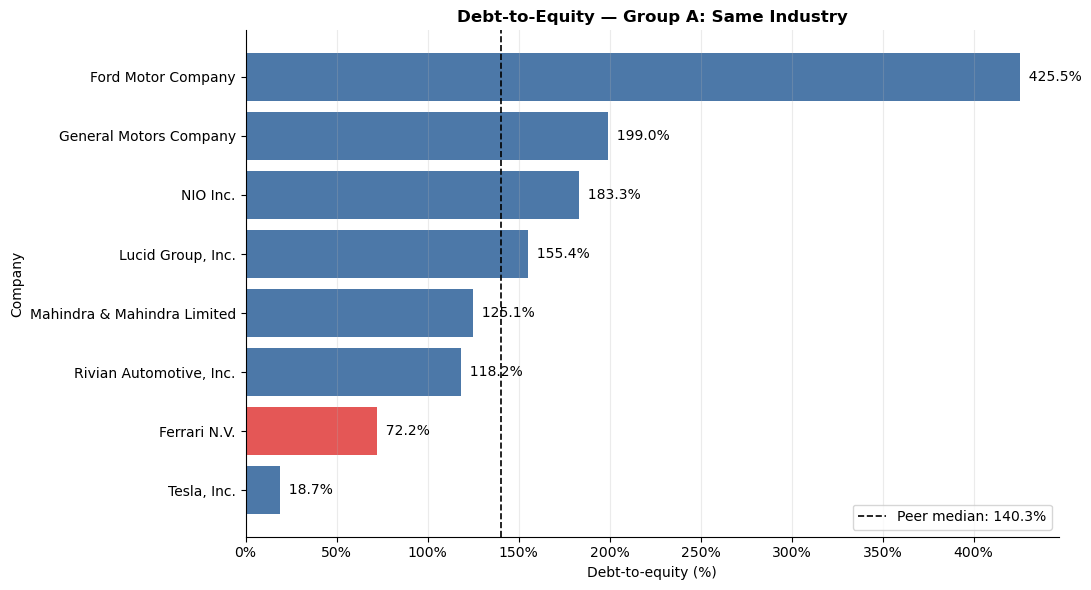

In [26]:
# ============================================================
# Step 6A — Debt-to-Equity: Group A, Same Industry
# ============================================================

metric = "debt_to_equity"

# Remove missing values only for the metric used in this chart.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort debt-to-equity in ascending order.
# Lower values are generally preferable.
plot_df = plot_df.sort_values(metric, ascending=True)

# Compute the peer median using available observations.
peer_median = plot_df[metric].median()

# Highlight Ferrari.
bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df[metric],
    color=bar_colors
)

# Add peer median line.
ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}%"
)

ax.set_title("Debt-to-Equity — Group A: Same Industry")
ax.set_xlabel("Debt-to-equity (%)")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)
annotate_hbar(ax, fmt="{:.1f}%")

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

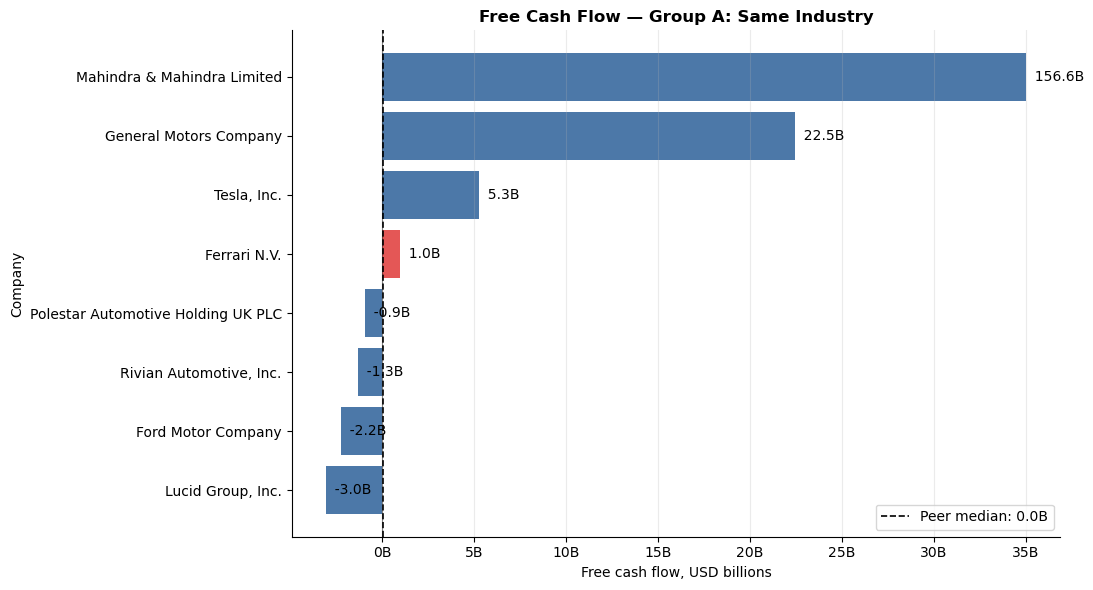

In [ ]:
# ============================================================
# Step 6B — Free Cash Flow: Group A, Same Industry
# ============================================================

metric = "free_cashflow_b"

# Remove missing values only for the metric used in this chart.
plot_df = group_a_industry.dropna(subset=[metric]).copy()

# Sort free cash flow in ascending order.
# Higher values are preferable, so the strongest cash generators appear at the top of the chart.
plot_df = plot_df.sort_values(metric, ascending=True)

# Compute the peer median using the original, uncapped values.
peer_median = plot_df[metric].median()

# Cap values only for visualization.
# Mahindra has a very large free cash flow value, which compresses the rest of the chart.
# The capped column is used only to improve readability.
fcf_cap_upper = 35
fcf_cap_lower = -5

plot_df["free_cashflow_b_plot"] = plot_df[metric].clip(
    lower=fcf_cap_lower,
    upper=fcf_cap_upper
)

# Highlight Ferrari.
bar_colors = [
    "#E45756" if symbol == selected_symbol else "#4C78A8"
    for symbol in plot_df["symbol"]
]

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    plot_df["label"],
    plot_df["free_cashflow_b_plot"],
    color=bar_colors
)

# Add peer median line.
ax.axvline(
    peer_median,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Peer median: {peer_median:.1f}B"
)

# Add zero line to distinguish positive from negative free cash flow.
ax.axvline(
    0,
    color="black",
    linestyle="-",
    linewidth=0.8,
    alpha=0.45
)

ax.set_title("Free Cash Flow — Group A: Same Industry")
ax.set_xlabel("Free cash flow, USD billions")
ax.set_ylabel("Company")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)

clean_spines(ax)

# Add labels using the original values, not the capped plotting values.
for patch, value in zip(ax.patches, plot_df[metric]):
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    
    # Keep labels inside the visible plotting area when values are capped.
    label_x = min(max(width, fcf_cap_lower), fcf_cap_upper)
    
    ax.text(
        label_x,
        y,
        "  " + f"{value:.1f}B",
        va="center",
        fontsize=10
    )

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

### Interpretation — Financial Strength

Ferrari shows a relatively solid financial profile compared with its same-industry peers. Looking first at **debt-to-equity**, Ferrari reports a ratio of about **72.2%**, which is well below the peer median of approximately **140.3%**. Since lower debt-to-equity values are generally preferable, this suggests that Ferrari does not rely heavily on debt compared with the typical Auto Manufacturers peer. Several competitors show much higher leverage levels, while Tesla is the only peer with a clearly lower debt-to-equity ratio.

Ferrari also generates **positive free cash flow**, equal to about **1.0B USD**. This is an important signal because it shows that Ferrari is not only profitable on accounting metrics, but also able to generate cash. Ferrari’s free cash flow is above several peers with negative values, including Polestar, Rivian, Ford and Lucid. These negative values are not automatically a red flag, especially for growth-oriented companies that may be investing heavily, but they do indicate weaker short-term cash generation.

At the same time, Ferrari is not the strongest cash generator in absolute terms. Mahindra, General Motors and Tesla show higher free cash flow values, with Mahindra representing a very large outlier. For this reason, the free cash flow chart uses a capped x-axis for readability, while keeping the original values in the labels.

Overall, Ferrari’s financial profile appears **strong**. The company combines below-median leverage with positive free cash flow, supporting the view that its premium valuation is backed not only by profitability and brand strength, but also by a relatively solid financial structure.

## Final Summary

In this homework I selected **Ferrari** for the company fundamental deep dive. Ferrari belongs to the assigned European geographic group and operates in the **Auto Manufacturers** industry. The choice was motivated by one of the main insights developed in Homework 1: broad sector or industry classifications can hide very different business models, financial profiles and risk-return characteristics. In Homework 1, the Real Estate analysis showed that companies within the same broad sector could differ substantially in terms of market capitalization, revenue, profitability and beta. The bubble chart also showed that companies could be positioned in very different risk-profitability quadrants, even when they belonged to the same overall sector.

Ferrari is therefore an interesting company for Homework 2 because it allows this idea to be tested at the individual-company level. Although Ferrari is classified as an auto manufacturer, its business model does not fully resemble that of a traditional mass-market car producer or a high-growth EV company. Ferrari has a premium and luxury-oriented positioning, based on brand exclusivity, pricing power and limited production volumes. For this reason, the deep dive investigates whether Ferrari’s fundamentals confirm this distinctive positioning and whether its premium valuation is supported by its fundamentals.

The profitability analysis shows that Ferrari is financially strong relative to its peers. Its **profit margin** is about **22.2%**, above the median in all three peer groups. The difference is especially clear within the Auto Manufacturers group, where the peer median is negative. Ferrari also reports a **return on equity** of about **42.0%**, again above the median in all three comparison groups. These results are consistent across metrics and suggest that Ferrari is not only profitable in absolute terms, but also significantly more profitable than the typical peer.

From a valuation perspective, Ferrari appears **expensive or premium-valued**. Its **P/E trailing** of about **33.3x** is slightly above the same-industry median, while its **price-to-book** of about **13.1x** is much higher than the peer median. However, this premium valuation does not appear completely unsupported. The profitability results show that Ferrari has stronger margins and ROE than most peers. 

At the same time, the growth analysis shows that Ferrari’s **revenue growth is positive but moderate**, around **3.2%**, and below the median in all three peer groups. This is consistent with Ferrari being a mature company that prioritizes stability and exclusivity over aggressive volume expansion.

The financial strength analysis does not raise major concerns. Ferrari’s **debt-to-equity** ratio is about **72.2%**, below the same-industry median, suggesting that the company does not rely excessively on debt compared with other auto manufacturers. Ferrari also generates **positive free cash flow**, around **1.0B USD**, which supports the view that its profitability is backed by cash generation. However, Ferrari is not the largest cash generator in absolute terms, as some peers show higher free cash flow values.

Overall, Ferrari appears to be a high-quality company with strong profitability, positive cash generation and a relatively solid financial structure. Its valuation is high, but this premium is partly justified by its brand strength, pricing power and superior margins. The main limitation is that revenue growth is moderate, suggesting that Ferrari’s investment story is based more on quality, resilience and stability than on aggressive expansion.

Finally, Ferrari had valid observations for all the key metrics used in the analysis. Some peer companies had unavailable or invalid values, especially for valuation multiples, and these were removed only in the specific charts where the metric was used. This reduced the number of comparable peers in some charts, but it did not prevent the analysis from evaluating Ferrari across profitability, valuation, growth and financial strength.


